<a href="https://colab.research.google.com/github/carolembomegni/Projet_SD_Detection_Tumeurs/blob/Francois-Projet/Model_RestNet50clahe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import gdown
import zipfile
import os

file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"

output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Détection du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = f"/content/{possible_dirs[0]}"
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=39b5ceac-b662-4a9c-9ee0-fa485615c0fb
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:01<00:00, 76.5MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


In [25]:
import os

import shutil

from pathlib import Path

# =====================================

# CHEMINS

# =====================================

src_root = Path(DATA_PATH)      # chemin détecté automatiquement par le bloc d'import

dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]

tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]

no_tumor_folder = "no_tumor"

# =====================================

# NETTOYAGE SI LE DOSSIER EXISTE DEJA

# =====================================

if dst_root.exists():

    shutil.rmtree(dst_root)

# =====================================

# CREATION DES DOSSIERS DE DESTINATION

# =====================================

for split in splits:

    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)

    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

# =====================================

# FONCTION DE COPIE SECURISEE

# =====================================

def safe_copy(src_file: Path, dst_dir: Path):

    dst_file = dst_dir / src_file.name

    if dst_file.exists():

        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"

    shutil.copy2(src_file, dst_file)

# =====================================

# FUSION DES CLASSES EN BINAIRE

# =====================================

for split in splits:

    # Fusion des classes tumor

    for cls in tumor_folders:

        cls_path = src_root / split / cls

        if cls_path.exists():

            for img in cls_path.rglob("*"):

                if img.is_file():

                    safe_copy(img, dst_root / split / "tumor")

    # Copie de la classe no_tumor

    cls_path = src_root / split / no_tumor_folder

    if cls_path.exists():

        for img in cls_path.rglob("*"):

            if img.is_file():

                safe_copy(img, dst_root / split / "no_tumor")

# =====================================

# VERIFICATION

# =====================================

print("✅ Fusion binaire terminée.")

print("Dossier source :", src_root)

print("\nTraining classes :", os.listdir(dst_root / "Training"))

print("Testing classes  :", os.listdir(dst_root / "Testing"))

print("\nNombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))

print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))

print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))

print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))




✅ Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri

Training classes : ['tumor', 'no_tumor']
Testing classes  : ['tumor', 'no_tumor']

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


In [26]:
import tensorflow as tf

import os

# ==============================

# CHEMINS DU DATASET BINAIRE

# ==============================

train_dir = "/content/Binary/Training"

test_dir  = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))

print("Classes test  :", os.listdir(test_dir))

# ==============================

# CHARGEMENT DU DATASET TRAIN

# ==============================

train_ds = tf.keras.utils.image_dataset_from_directory(

    train_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=True,

    seed=42

)

# ==============================

# CHARGEMENT DU DATASET TEST

# ==============================

test_ds = tf.keras.utils.image_dataset_from_directory(

    test_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=False

)

Classes train : ['tumor', 'no_tumor']
Classes test  : ['tumor', 'no_tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


In [27]:
from PIL import Image
from pathlib import Path

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = Path("/content/Binary/Training")
test_dir  = Path("/content/Binary/Testing")

# ==============================
# FONCTION SUPPRESSION IMAGES CORROMPUES
# ==============================
def remove_corrupted_images(folder):
    removed = 0
    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("❌ Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1
    return removed

# ==============================
# EXECUTION
# ==============================
removed_train = remove_corrupted_images(train_dir)
removed_test  = remove_corrupted_images(test_dir)

print("\n✅ Nettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


✅ Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


##Application du clahe

In [28]:
#Appliquer CLAHE sur le dataset binaire
import cv2
import shutil
from pathlib import Path

# ==============================
# CHEMINS
# ==============================
src_root = Path("/content/Binary")
clahe_root = Path("/content/Binary_CLAHE")

# Nettoyage si le dossier existe déjà
if clahe_root.exists():
    shutil.rmtree(clahe_root)

# ==============================
# CREATION DES DOSSIERS
# ==============================
for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        (clahe_root / split / cls).mkdir(parents=True, exist_ok=True)

# ==============================
# FONCTION CLAHE
# ==============================
def apply_clahe_rgb(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    return img_clahe

# ==============================
# APPLICATION CLAHE
# ==============================
count_saved = 0

for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        src_folder = src_root / split / cls
        dst_folder = clahe_root / split / cls

        for img_path in src_folder.glob("*"):
            if img_path.is_file():
                img = cv2.imread(str(img_path))

                if img is None:
                    print("⚠️ Impossible de lire :", img_path)
                    continue

                img_clahe = apply_clahe_rgb(img)

                save_path = dst_folder / img_path.name
                cv2.imwrite(str(save_path), img_clahe)
                count_saved += 1

print("✅ CLAHE appliqué avec succès")
print("Nombre total d'images sauvegardées :", count_saved)
print("Nouveau dossier :", clahe_root)

✅ CLAHE appliqué avec succès
Nombre total d'images sauvegardées : 3264
Nouveau dossier : /content/Binary_CLAHE


Nombre images originales : 2475
Nombre images CLAHE      : 2475


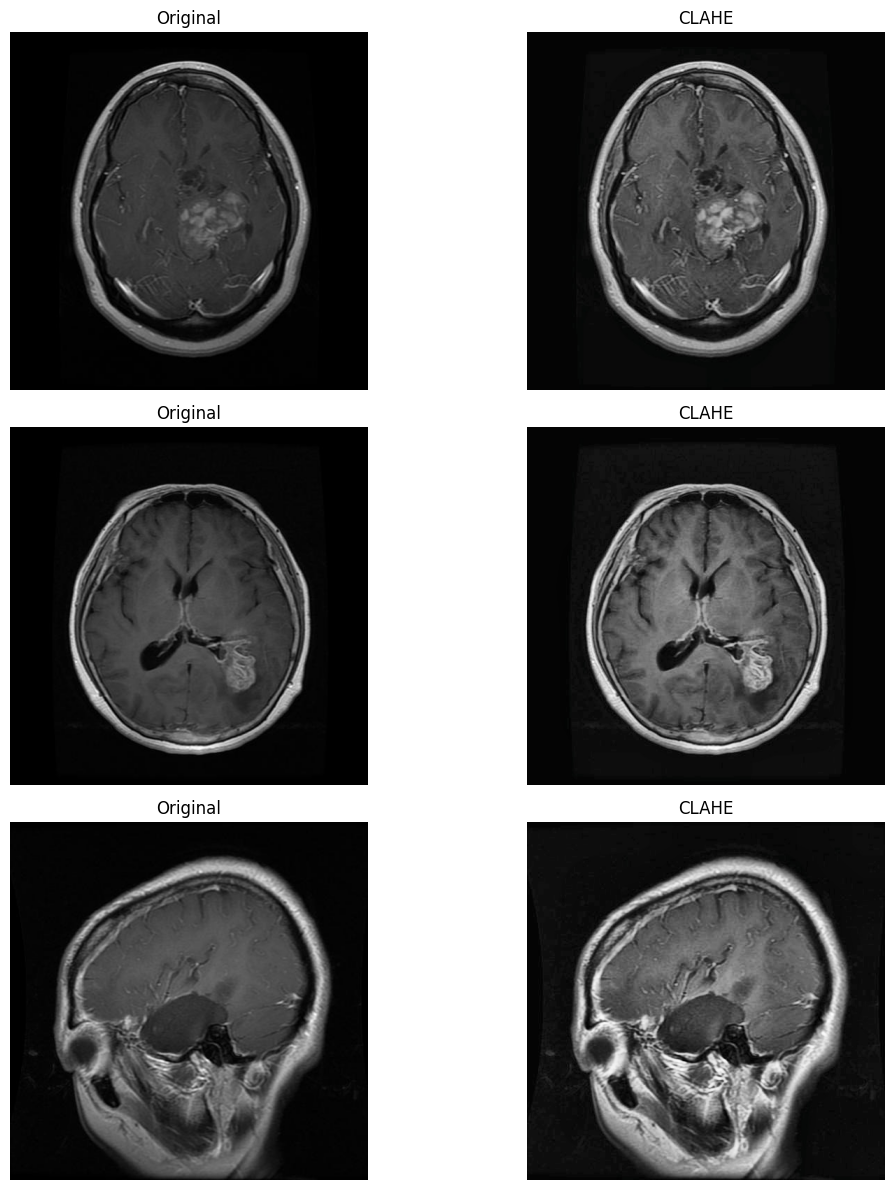

In [29]:
# verifier avant et apres clahe
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Exemple : prendre la première image disponible dans tumor
orig_folder = Path("/content/Binary/Training/tumor")
clahe_folder = Path("/content/Binary_CLAHE/Training/tumor")

orig_images = sorted(list(orig_folder.glob("*")))
clahe_images = sorted(list(clahe_folder.glob("*")))

print("Nombre images originales :", len(orig_images))
print("Nombre images CLAHE      :", len(clahe_images))

# Afficher 3 comparaisons
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(min(n, len(orig_images))):
    img_orig = cv2.imread(str(orig_images[i]))
    img_clahe = cv2.imread(str(clahe_images[i]))

    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)

    plt.subplot(n, 2, 2*i + 1)
    plt.imshow(img_orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(n, 2, 2*i + 2)
    plt.imshow(img_clahe)
    plt.title("CLAHE")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
#Nettoyer les images corrompues dans le dossier CLAHE
from PIL import Image
from pathlib import Path

# ==============================
# CHEMINS CLAHE
# ==============================
train_clahe_dir = Path("/content/Binary_CLAHE/Training")
test_clahe_dir  = Path("/content/Binary_CLAHE/Testing")

# ==============================
# FONCTION SUPPRESSION IMAGES CORROMPUES
# ==============================
def remove_corrupted_images(folder):
    removed = 0

    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("❌ Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1

    return removed

# ==============================
# EXECUTION
# ==============================
removed_train = remove_corrupted_images(train_clahe_dir)
removed_test  = remove_corrupted_images(test_clahe_dir)

print("\n✅ Nettoyage CLAHE terminé")
print("Images supprimées - Training_CLAHE :", removed_train)
print("Images supprimées - Testing_CLAHE  :", removed_test)


✅ Nettoyage CLAHE terminé
Images supprimées - Training_CLAHE : 0
Images supprimées - Testing_CLAHE  : 0


In [31]:
#Compter les images  Clahe
from pathlib import Path

for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        folder = Path(f"/content/Binary_CLAHE/{split}/{cls}")
        print(f"{split}/{cls} :", len(list(folder.glob('*'))))

Training/tumor : 2475
Training/no_tumor : 395
Testing/tumor : 289
Testing/no_tumor : 105


In [32]:
# Equilibrer les training_clahe
import shutil
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# ==============================
# DOSSIERS SOURCE CLAHE
# ==============================
train_no = Path("/content/Binary_CLAHE/Training/no_tumor")
train_tu = Path("/content/Binary_CLAHE/Training/tumor")

# ==============================
# DOSSIERS DESTINATION EQUILIBRES
# ==============================
balanced_root = Path("/content/Binary_CLAHE/Training_balanced")
balanced_no = balanced_root / "no_tumor"
balanced_tu = balanced_root / "tumor"

# Nettoyage si existe déjà
if balanced_root.exists():
    shutil.rmtree(balanced_root)

balanced_no.mkdir(parents=True, exist_ok=True)
balanced_tu.mkdir(parents=True, exist_ok=True)

# ==============================
# LISTE DES IMAGES
# ==============================
no_files = list(train_no.glob("*"))
tu_files = list(train_tu.glob("*"))

n_no = len(no_files)
n_tu = len(tu_files)

print("Nombre initial no_tumor :", n_no)
print("Nombre initial tumor    :", n_tu)

# ==============================
# COPIE DES IMAGES ORIGINALES
# ==============================
for f in no_files:
    shutil.copy2(f, balanced_no / f.name)

for f in tu_files:
    shutil.copy2(f, balanced_tu / f.name)

# ==============================
# DATA AUGMENTATION
# ==============================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

# ==============================
# FONCTION D'AUGMENTATION
# ==============================
def augment_until_target(files, output_dir, target_count, prefix):
    current_count = len(list(output_dir.glob("*")))
    i = 0

    while current_count < target_count:
        img_path = files[i % len(files)]
        img = load_img(img_path, target_size=(224, 224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        aug_iter = datagen.flow(x, batch_size=1)
        aug_img = next(aug_iter)[0].astype("uint8")

        save_path = output_dir / f"{prefix}_aug_{current_count}.jpg"
        save_img(save_path, aug_img)

        current_count += 1
        i += 1

# ==============================
# EQUILIBRAGE
# ==============================
target = max(n_no, n_tu)

if n_no < target:
    augment_until_target(no_files, balanced_no, target, "no_tumor")

if n_tu < target:
    augment_until_target(tu_files, balanced_tu, target, "tumor")

print("\n✅ Equilibrage CLAHE terminé")
print("no_tumor final :", len(list(balanced_no.glob('*'))))
print("tumor final    :", len(list(balanced_tu.glob('*'))))

Nombre initial no_tumor : 395
Nombre initial tumor    : 2475

✅ Equilibrage CLAHE terminé
no_tumor final : 2475
tumor final    : 2475


In [33]:
# Recharger les datasets CLAHE pour entraînement
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary_CLAHE/Training_balanced",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary_CLAHE/Training_balanced",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary_CLAHE/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes :", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Classes : ['no_tumor', 'tumor']


In [34]:
# Nettoyer la memoire
import tensorflow as tf
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()

0

In [35]:
# Modele ResNet50
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Base ResNet50
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Modèle complet
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [36]:
# Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [37]:
# Callsbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    ModelCheckpoint("/content/resnet_clahe_best.keras", save_best_only=True)
]

In [38]:
# Entrainement
class_weight = {0: 1.0, 1: 1.5}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 31s 191ms/step - accuracy: 0.8407 - loss: 0.4439 - val_accuracy: 0.9566 - val_loss: 0.1485 - learning_rate: 1.0000e-04
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.9366 - loss: 0.2119 - val_accuracy: 0.9677 - val_loss: 0.0997 - learning_rate: 1.0000e-04
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.9465 - loss: 0.1751 - val_accuracy: 0.9727 - val_loss: 0.0861 - learning_rate: 1.0000e-04
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - accuracy: 0.9508 - loss: 0.1510 - val_accuracy: 0.9768 - val_loss: 0.0705 - learning_rate: 1.0000e-04
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 178ms/step - accuracy: 0.9596 - loss: 0.1277 - val_accuracy: 0.9798 - val_loss: 0.0678 - learning_rate: 1.0000e-04
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 177ms/step - accuracy: 0.9689 - loss: 0.1128 - val_accuracy: 0.9778 - val_loss: 0.0621 - learning_rate: 1.0000e-04
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 17

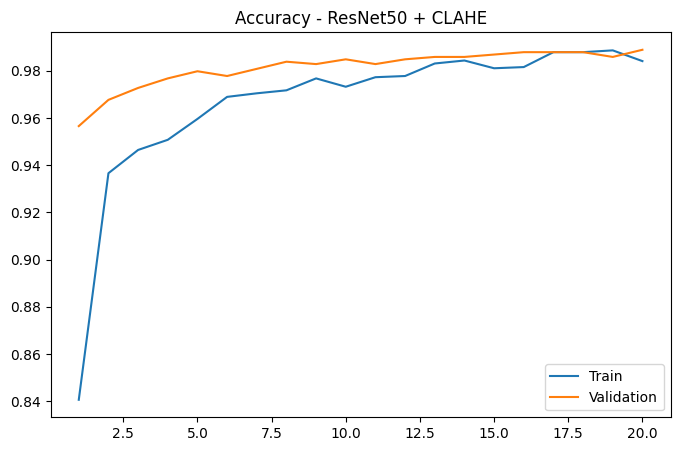

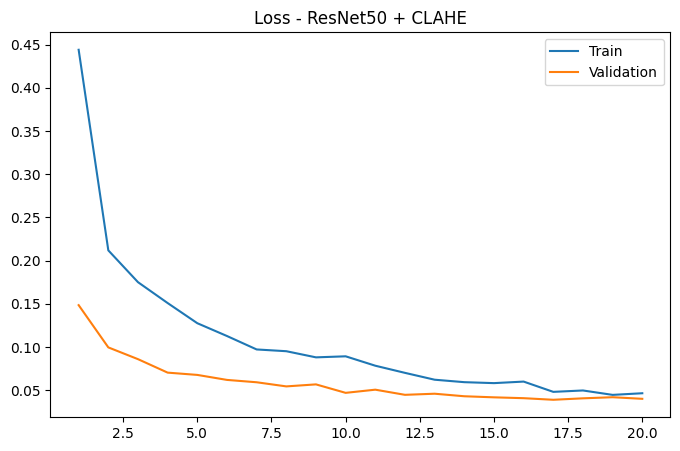

In [39]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label="Train")
plt.plot(epochs_range, val_acc, label="Validation")
plt.title("Accuracy - ResNet50 + CLAHE")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label="Train")
plt.plot(epochs_range, val_loss, label="Validation")
plt.title("Loss - ResNet50 + CLAHE")
plt.legend()
plt.show()

In [40]:
# Evaluation
test_loss, test_acc = model.evaluate(test_ds)
print("Accuracy ResNet50 + CLAHE :", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.9188 - loss: 0.2830
Accuracy ResNet50 + CLAHE : 0.9187816977500916


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 300ms/step

===== Seuil = 0.5 =====
Precision tumor : 0.9961389961389961
Recall tumor    : 0.8927335640138409
F1-score tumor  : 0.9416058394160584
Matrice de confusion :
[[104   1]
 [ 31 258]]

===== Seuil = 0.4 =====
Precision tumor : 0.9962121212121212
Recall tumor    : 0.9100346020761245
F1-score tumor  : 0.9511754068716094
Matrice de confusion :
[[104   1]
 [ 26 263]]

===== Seuil = 0.3 =====
Precision tumor : 0.9713261648745519
Recall tumor    : 0.9377162629757786
F1-score tumor  : 0.954225352112676
Matrice de confusion :
[[ 97   8]
 [ 18 271]]

===== Seuil = 0.2 =====
Precision tumor : 0.9413793103448276
Recall tumor    : 0.9446366782006921
F1-score tumor  : 0.9430051813471503
Matrice de confusion :
[[ 88  17]
 [ 16 273]]

===== Seuil = 0.15 =====
Precision tumor : 0.9256756756756757
Recall tumor    : 0.9480968858131488
F1-score tumor  : 0.9367521367521368
Matrice de confusion :
[[ 83  22]
 [ 15 274]]

===== Seuil = 0.1 =====
Precision tumor : 0.9172

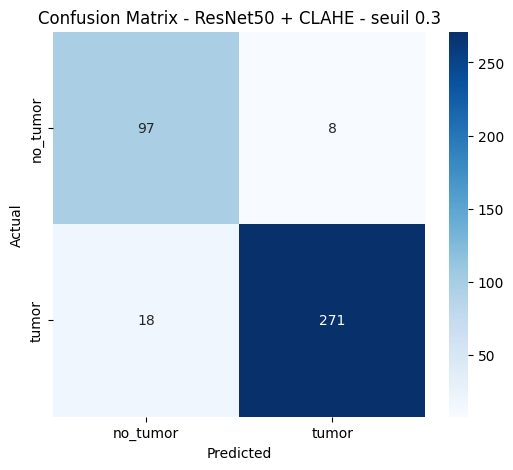

In [41]:
# Optimisation du seuil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# vraies étiquettes + probabilités
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds).ravel()

# tester plusieurs seuils
thresholds = [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]
results = []

for threshold in thresholds:
    y_pred = (y_prob > threshold).astype(int)

    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)

    print(f"\n===== Seuil = {threshold} =====")
    print("Precision tumor :", precision)
    print("Recall tumor    :", recall)
    print("F1-score tumor  :", f1)
    print("Matrice de confusion :")
    print(confusion_matrix(y_true, y_pred))

    results.append((threshold, precision, recall, f1))

# choisir le meilleur seuil
best_threshold = max(results, key=lambda x: x[3])[0]   # F1-score
print("\n✅ Meilleur seuil choisi :", best_threshold)

# rapport final
y_pred_best = (y_prob > best_threshold).astype(int)

print("\n📊 Classification Report final :")
print(classification_report(y_true, y_pred_best, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - ResNet50 + CLAHE - seuil {best_threshold}")
plt.show()

Le modèle ResNet50 entraîné avec CLAHE présente une amélioration significative des performances, notamment avec un rappel de 0.95 pour la classe tumor et une réduction des faux négatifs à 18. Contrairement à DenseNet121, l’application de CLAHE a permis ici d’améliorer la détection des tumeurs. Ce modèle constitue ainsi la meilleure solution dans ce projet en contexte médical.